# 0. Libraries & Settings

In [1]:
%load_ext autoreload
%autoreload 2

from car_price_model.data_io.reading import read_data_from_directory
import car_price_model.processing.cleaning as cleaning
import car_price_model.data_io.reading as reading
from matplotlib import pyplot as plt
from car_price_model.processing.outliers import remove_outliers_iqr, trim_outliers, remove_top_n_outliers
import car_price_model.utils.utils as utils
import pandas as pd
from matplotlib import pyplot as plt
# show all panda columns
pd.set_option('display.max_columns', None)
import seaborn as sns
import numpy as np
import sublimeplot as sp
import matplotlib
from scipy.stats import gaussian_kde


# 1. Reading data

- Data is read with `read_dataset` function from file [listings.parquet](../data/interim/listings.parquet)
- Data has already been mapped, cleaned and preprocessed. For more information, see  [cleaning.py](../src/car_price_model/processing/cleaning.py)

In [2]:
df = reading.read_dataset("data/interim/listings.parquet")
df.head()

,age,cv,km,fuel,doors,gearbox,emissions,color,brand,price,boot,length,height,width,seats,max_sp,cmixto,curban,extraurban,zero_to_hundred,displac,max_par,gear,class,location,n_cylinders,cylinder_layout
0,5,184,74,gasoline,2,automatic,129,blue,mercedes,37900,400,469,141,181,4,235,5.8,7.5,4.7,7.3,1991,300,9,sport,[islas baleares],4,inline
1,3,122,58,gasoline,4,automatic,126,black,mercedes,32990,470,463,143,178,5,210,5.5,7.1,4.6,8.7,1595,200,7,sport,[islas baleares],4,inline
2,7,110,67,diesel,2,manual,112,gray,volkswagen,22790,225,428,147,181,4,180,4.3,5.0,4.1,11.7,1968,250,5,sport,[islas baleares],4,inline
3,12,200,47,gasoline,2,manual,155,gray,peugeot,21900,321,429,136,185,4,237,6.9,8.8,5.6,7.5,1598,275,6,sport,[islas baleares],4,inline
4,6,140,49,gasoline,2,manual,149,blue,opel,17990,280,470,144,184,4,207,6.3,7.8,5.4,10.9,1362,200,6,sport,[islas baleares],4,inline


### 1.1 Table Schema


This dataset contains **52,239** car listings scraped from [coches.com](https://coches.com) in **2023**, where **each row is an individual listing** for a used vehicle. Each listing includes vehicle specifications (power, dimensions, fuel consumption, emissions, engine details), descriptive attributes (brand, color, class, year), and the listing price. The location field is list-like because a single listing can be published in multiple locations simultaneously.


| Variable | Type | Description | Units/Example |
|----------|------|-------------|---------------|
| `age` | object | Age of the vehicle | e.g. `2018` |
| `cv` | int64 | Engine power in *caballos de vapor* | e.g. `184` |
| `km` | int64 | Mileage of the vehicle (in thousands of km) | e.g. `74` |
| `fuel` | object | Fuel type | `gasoline`, `diesel` |
| `doors` | int64 | Number of doors | `2`, `4`, `5` |
| `gearbox` | object | Transmission type | `automatic`, `manual` |
| `emissions` | int64 | CO₂ emissions | g/km, e.g. `129` |
| `color` | object | Exterior color | `blue`, `black`, `gray` |
| `brand` | object | Manufacturer | `mercedes`, `opel` |
| `price` | int64 | Listing price | euros (€), e.g. `37900` |
| `boot` | int64 | Boot/trunk capacity | liters, e.g. `400` |
| `length` | int64 | Vehicle length | cm, e.g. `469` |
| `height` | int64 | Vehicle height | cm, e.g. `141` |
| `width` | int64 | Vehicle width | cm, e.g. `181` |
| `seats` | int64 | Number of seats | e.g. `5` |
| `max_sp` | int64 | Maximum speed | km/h, e.g. `235` |
| `cmixto` | float64 | Combined fuel consumption | L/100km, e.g. `5.8` |
| `curban` | float64 | Urban fuel consumption | L/100km, e.g. `7.5` |
| `extraurban` | float64 | Extra-urban (highway) fuel consumption | L/100km, e.g. `4.7` |
| `zero_to_hundred` | float64 | Acceleration time from 0 to 100 km/h | seconds, e.g. `7.3` |
| `displac` | int64 | Engine displacement | cc, e.g. `1991` |
| `max_par` | int64 | Maximum torque (*par máximo*) | Nm, e.g. `300` |
| `gear` | int64 | Number of gears | e.g. `9` |
| `class` | object | Vehicle class/segment | `sport` |
| `location` | object | Location(s) where listing is published (list; can be multiple) | `[islas baleares]` |
| `n_cylinders` | int64 | Number of cylinders | e.g. `4` |
| `cylinder_layout` | object | Cylinder configuration | `inline` |



# 2. Data Quality Assestment

In [3]:
print(f"Null values have already been removed, {df.isnull().sum().sum()} null values found")
print(f"After deduplication: {len(df):,} rows remain with {len(df)-len(df.drop(columns=['location']).drop_duplicates())} current duplicates")

Null values have already been removed, 0 null values found
After deduplication: 52,239 rows remain with 0 current duplicates


In [4]:
df.age.min()

np.int64(0)

In [5]:
df.describe()

,age,cv,km,doors,emissions,price,boot,length,height,width,seats,max_sp,cmixto,curban,extraurban,zero_to_hundred,displac,max_par,gear,n_cylinders
count,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.00000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000
mean,5.941481,140.257662,83.606979,4.733800,123.050135,21702.142403,433.243458,437.056778,154.303873,180.853998,4.97433,195.914068,5.007582,6.049806,4.332189,10.073361,1669.632076,287.033117,6.052815,3.921400
std,3.654752,61.628720,62.825852,0.691548,32.692118,14349.722681,149.540726,31.731856,10.780293,7.311909,0.52278,22.722497,1.357669,2.066894,1.098382,2.604427,546.631246,317.682937,1.306193,0.747077
min,0.000000,41.000000,1.000000,2.000000,0.000000,500.000000,32.000000,250.000000,114.000000,150.000000,2.00000,118.000000,1.100000,0.000000,0.000000,0.000000,698.000000,0.000000,1.000000,2.000000
25%,4.000000,109.000000,39.000000,5.000000,105.000000,13900.000000,350.000000,417.000000,146.000000,177.000000,5.00000,181.000000,4.200000,4.800000,3.700000,8.900000,1364.000000,200.000000,5.000000,4.000000
50%,5.000000,130.000000,73.000000,5.000000,116.000000,18990.000000,420.000000,438.000000,151.000000,181.000000,5.00000,192.000000,4.800000,5.700000,4.100000,10.400000,1560.000000,250.000000,6.000000,4.000000
75%,7.000000,150.000000,114.000000,5.000000,133.000000,25990.000000,510.000000,459.000000,162.000000,184.000000,5.00000,208.000000,5.500000,6.700000,4.800000,11.500000,1969.000000,330.000000,6.000000,4.000000
max,54.000000,720.000000,994.000000,5.000000,495.000000,565000.000000,2500.000000,540.000000,200.000000,224.000000,9.00000,350.000000,21.300000,31.000000,15.000000,20.000000,6592.000000,12164.000000,10.000000,12.000000


All extreme values (both min and max) fall in reasonable ranges. There might be some exceptions on the following columns `emissions`, `curban`, `extraurban`, `zero_to_hundred`, `seats`, `doors`, `height`, `max_par` but it won't be problematic since those columns are being dropped after checking their correlation.

# 3. Multivariate analysis

In [6]:
# move price to the end 
df = df[[col for col in df.columns if col != 'price'] + ['price']]

In [7]:
def plot_correlation_matrix(df, full_matrix=True):
    plt.figure(figsize=(14,10*full_matrix+1))
    corr = df.select_dtypes(np.number).corr().round(2)
    if not full_matrix:
        corr = corr.iloc[[-1]]
    sns.heatmap(corr, annot=True, cmap='RdBu', center = 0, vmin=-1, vmax=1)
    sns.set_theme(font="IBM Plex Sans")
    plt.show()
    matplotlib.rc_file_defaults()

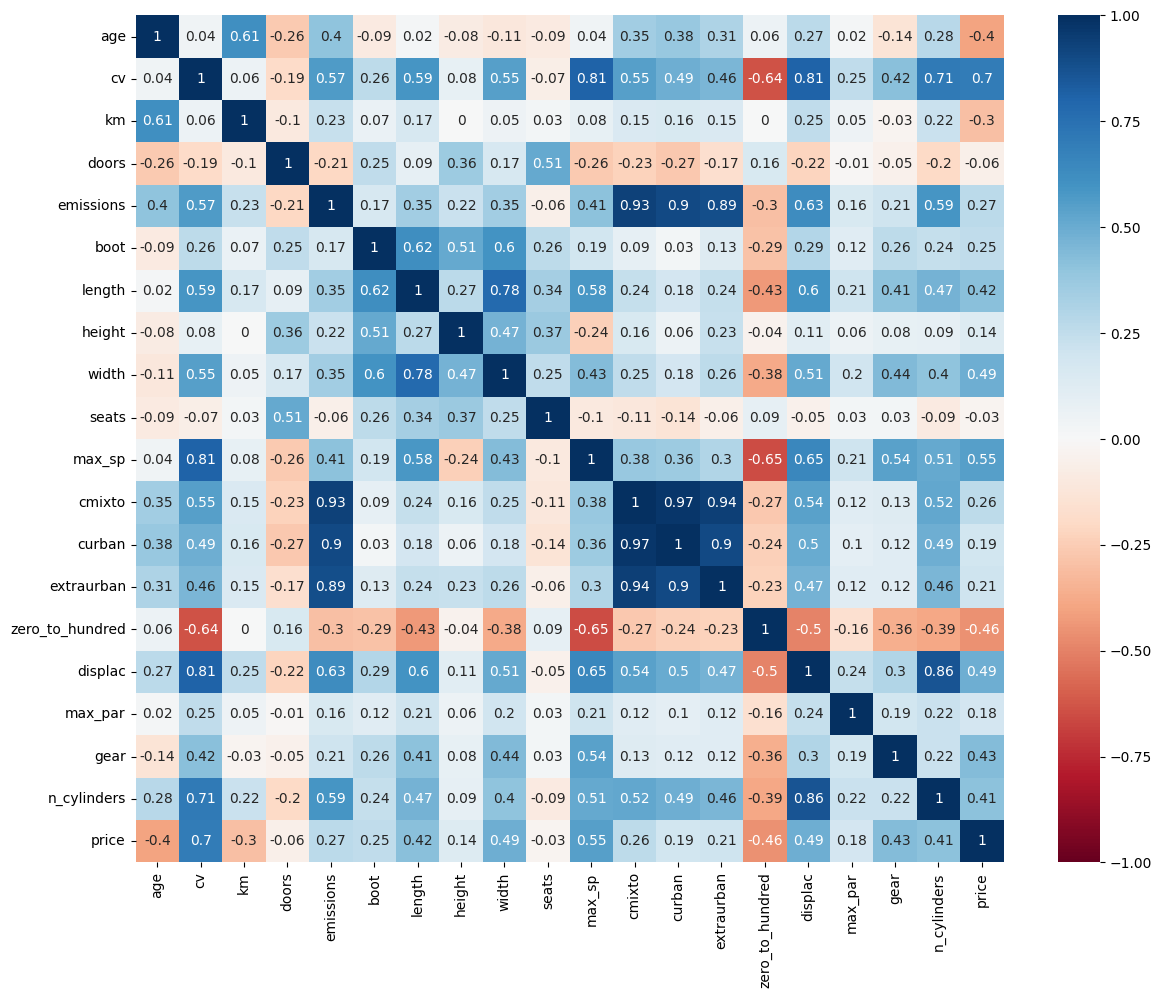

In [8]:
plot_correlation_matrix(df)


I will be dropping the columns `curban`, `extraurban`, `seats`, `doors`, `height` and `max_par` because they have a low correlation with the target **price** as we can see below:

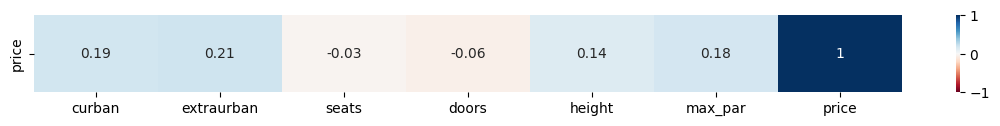

In [9]:
columns = ["curban", "extraurban", "seats", "doors", "height", "max_par","price"]
plot_correlation_matrix(df[columns], full_matrix=False)

I will also be droppin the columns `emissions` since they are heavily correlated to other existing columns like `cmixto`

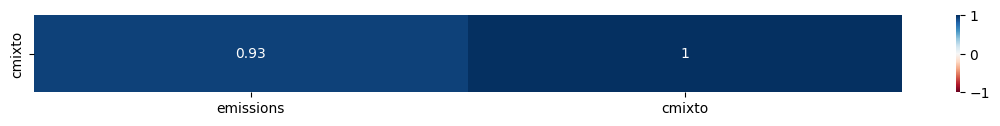

In [10]:
plot_correlation_matrix(df[["emissions","cmixto"]], full_matrix=False)

In [11]:
cols_to_drop = ["emissions", "curban", "extraurban", "seats", "doors", "height", "max_par"]
df = df.drop(cols_to_drop, axis=1)

This leaves us 20 columns, with a cleaner correlation matrix that looks like this:

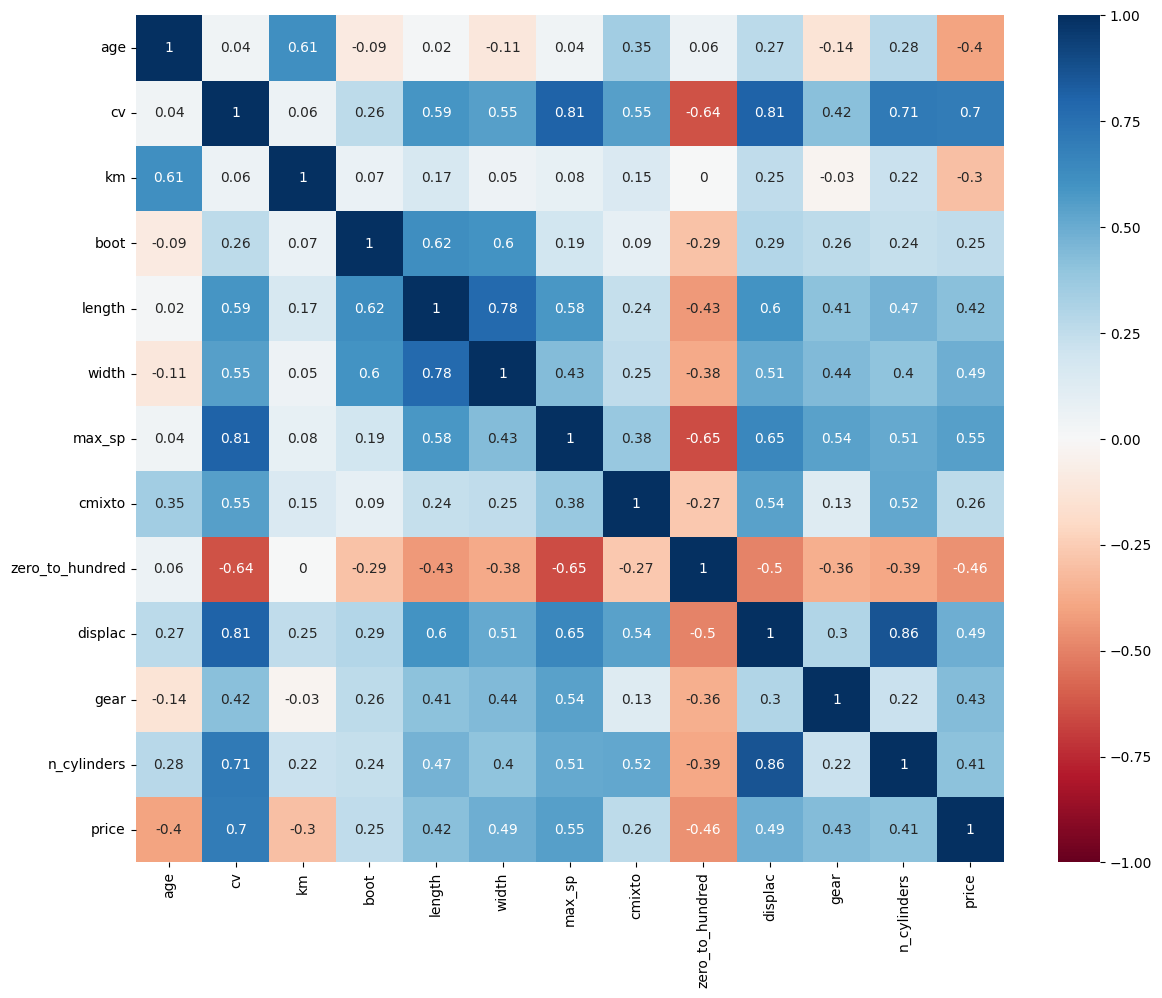

In [12]:
plot_correlation_matrix(df)

# 4. Outlier detection

In [13]:
def kde_curve(data, bw_adjust=1.0, gridsize=500):
    """Compute a KDE curve for plotting."""
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    kde = gaussian_kde(data)
    kde.set_bandwidth(kde.factor * bw_adjust)
    x = np.linspace(data.min(), data.max(), gridsize)
    return x, kde(x)

For our target variable `price`, there's a decent amount of outliers on the higher end (up to half a million euros, cars that really don't belong in this dataset). As we can see below, the distribution is heavily right-skewed, following a **log-normal pattern**. The same happens to the `boot` capacity column, although not as severe.

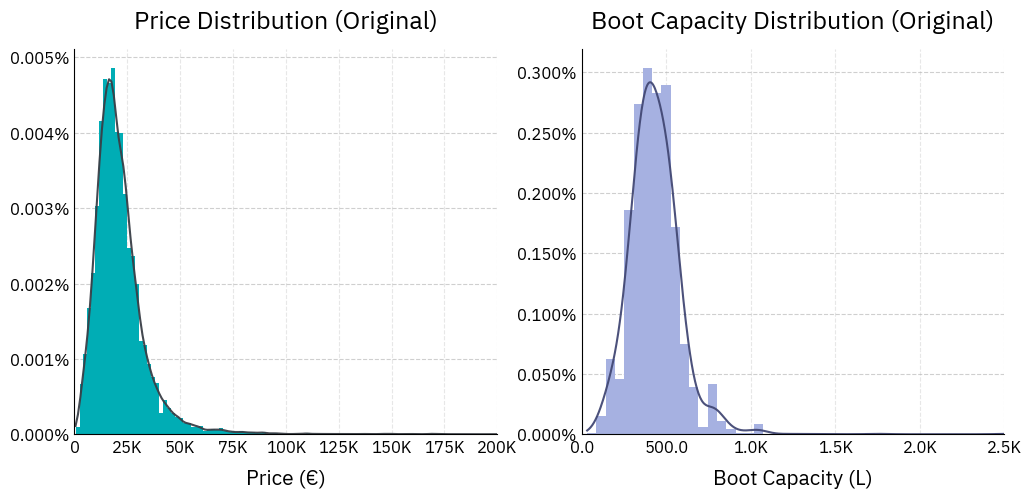

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
color_1, color_2 = "#00ADB5", "#393E46"
var="price"
ax = df[var].hist(bins=300, density=True, zorder=2, color=color_1)
x, y = kde_curve(df[var], bw_adjust=1)
plt.plot(x, y, zorder=2, color=color_2, alpha=0.95)
sp.config.fontname = "IBM Plex Sans"
sp.style_hist(ax, yformat=sp.formats.percent(decimals=3), xformat=sp.formats.human(decimals=0), xtitle="Price (€)", title="Price Distribution (Original)")
plt.xlim(0, 200000)

plt.subplot(1, 2, 2)
color_1, color_2 = "#A6B1E1", "#424874"
var="boot"
ax = df[var].hist(bins=45, density=True, zorder=2, color=color_1)
x,y = kde_curve(df[var], bw_adjust=3.4)
plt.plot(x, y, zorder=2, color=color_2, alpha=0.95)
sp.config.fontname = "IBM Plex Sans"
sp.style_hist(ax, yformat=sp.formats.percent(decimals=3), xformat=sp.formats.human(decimals=1), xtitle="Boot Capacity (L)", title="Boot Capacity Distribution (Original)")
plt.xlim(0, df[var].max())
plt.show()


Since these distributions behave like a log-normal distribution, a **traditional IQR outlier detection method is not going to be the best approach** (it would remove too many data points). 

Instead, we will use the **trimming method** to **remove the top 1%** of the data.

In [15]:
df = trim_outliers(df, "price", upper_quantile=0.99)
df = trim_outliers(df, "boot", upper_quantile=0.99)

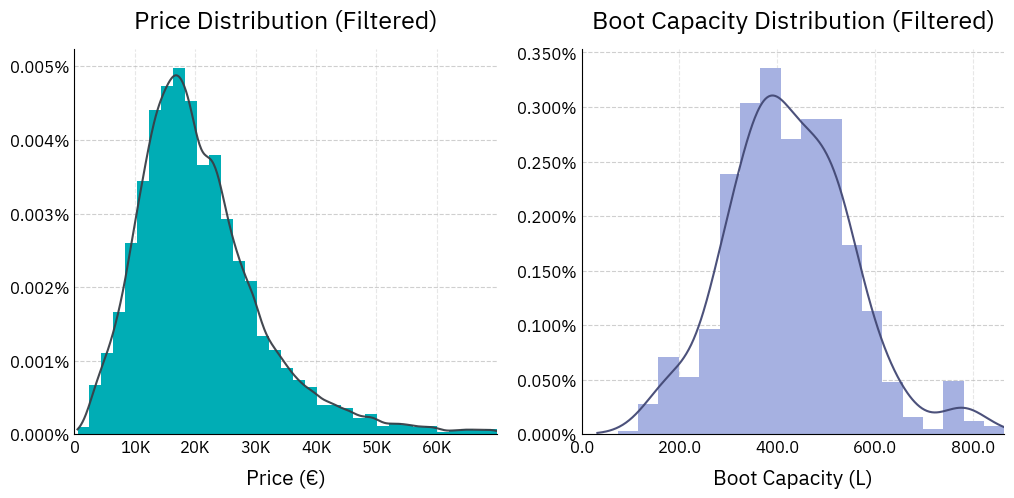

In [16]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
color_1, color_2 = "#00ADB5", "#393E46"
var = "price"
ax = df[var].hist(bins=35, density=True, zorder=2, color=color_1)
x,y = kde_curve(df[var], bw_adjust=1)
plt.plot(x, y, color=color_2, alpha=0.95)
sp.config.fontname = "IBM Plex Sans"
sp.style_hist(ax, yformat=sp.formats.percent(decimals=3), xformat=sp.formats.human(decimals=0), xtitle="Price (€)", title="Price Distribution (Filtered)")
plt.xlim(0, df[var].max())

plt.subplot(1, 2, 2)
color_1, color_2 = "#A6B1E1", "#424874"
var = "boot"
ax = df[var].hist(bins=20, density=True, zorder=2, color=color_1)
x,y = kde_curve(df[var], bw_adjust=3)
plt.plot(x, y, color=color_2, alpha=0.95)
sp.config.fontname = "IBM Plex Sans"
sp.style_hist(ax, yformat=sp.formats.percent(decimals=3), xformat=sp.formats.human(decimals=1), xtitle="Boot Capacity (L)", title="Boot Capacity Distribution (Filtered)")
plt.xlim(0, df[var].max())
plt.show()


In [17]:
df

,age,cv,km,fuel,gearbox,color,brand,boot,length,width,max_sp,cmixto,zero_to_hundred,displac,gear,class,location,n_cylinders,cylinder_layout,price
0,5,184,74,gasoline,automatic,blue,mercedes,400,469,181,235,5.8,7.3,1991,9,sport,[islas baleares],4,inline,37900
1,3,122,58,gasoline,automatic,black,mercedes,470,463,178,210,5.5,8.7,1595,7,sport,[islas baleares],4,inline,32990
2,7,110,67,diesel,manual,gray,volkswagen,225,428,181,180,4.3,11.7,1968,5,sport,[islas baleares],4,inline,22790
3,12,200,47,gasoline,manual,gray,peugeot,321,429,185,237,6.9,7.5,1598,6,sport,[islas baleares],4,inline,21900
4,6,140,49,gasoline,manual,blue,opel,280,470,184,207,6.3,10.9,1362,6,sport,[islas baleares],4,inline,17990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52234,6,116,113,diesel,manual,white,bmw,360,433,177,200,4.2,10.5,1496,6,standard,[malaga],3,inline,17900
52235,4,116,73,gasoline,manual,white,volkswagen,605,457,180,197,4.8,10.4,999,6,standard,[malaga],3,inline,18700
52236,9,75,175,diesel,manual,white,opel,285,402,175,164,3.8,14.8,1248,5,standard,[malaga],4,inline,7500
52237,8,71,40,gasoline,manual,black,other,190,270,166,151,5.0,14.9,999,5,standard,[malaga],3,inline,10200


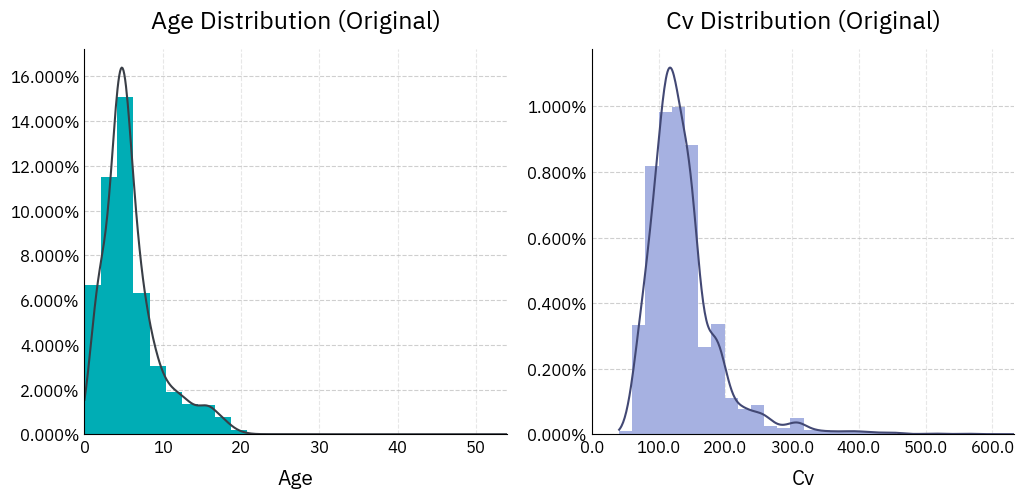

In [18]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
color_1, color_2 = "#00ADB5", "#393E46"
var = "age"
ax = df[var].hist(bins=26, density=True, zorder=2, color=color_1)
x,y = kde_curve(df[var], bw_adjust=2)
plt.plot(x, y, color=color_2)
sp.config.fontname = "IBM Plex Sans"
sp.style_hist(ax, yformat=sp.formats.percent(decimals=3), xformat=sp.formats.human(decimals=0), xtitle=var.capitalize(), title=f"{var.capitalize()} Distribution (Original)")
plt.xlim(0, df[var].max())

plt.subplot(1, 2, 2)
var = "cv"
color_1, color_2 = "#A6B1E1", "#424874"
ax = df[var].hist(bins=30, density=True, zorder=2, color=color_1)
x,y = kde_curve(df[var], bw_adjust=2)
plt.plot(x, y, color=color_2)
sp.config.fontname = "IBM Plex Sans"
sp.style_hist(ax, yformat=sp.formats.percent(decimals=3), xformat=sp.formats.human(decimals=1), xtitle=f"{var.capitalize()}", title=f"{var.capitalize()} Distribution (Original)")
plt.xlim(0, df[var].max())
plt.show()


For the rest of numerical values, we can see that they are quite naturally distributed. There are always extreme values, but they look like legitimate data points. There is only **one exception** that stands out: one car with an **age greater than 50 years**, so far from the distribution that makes no sense to keep it.

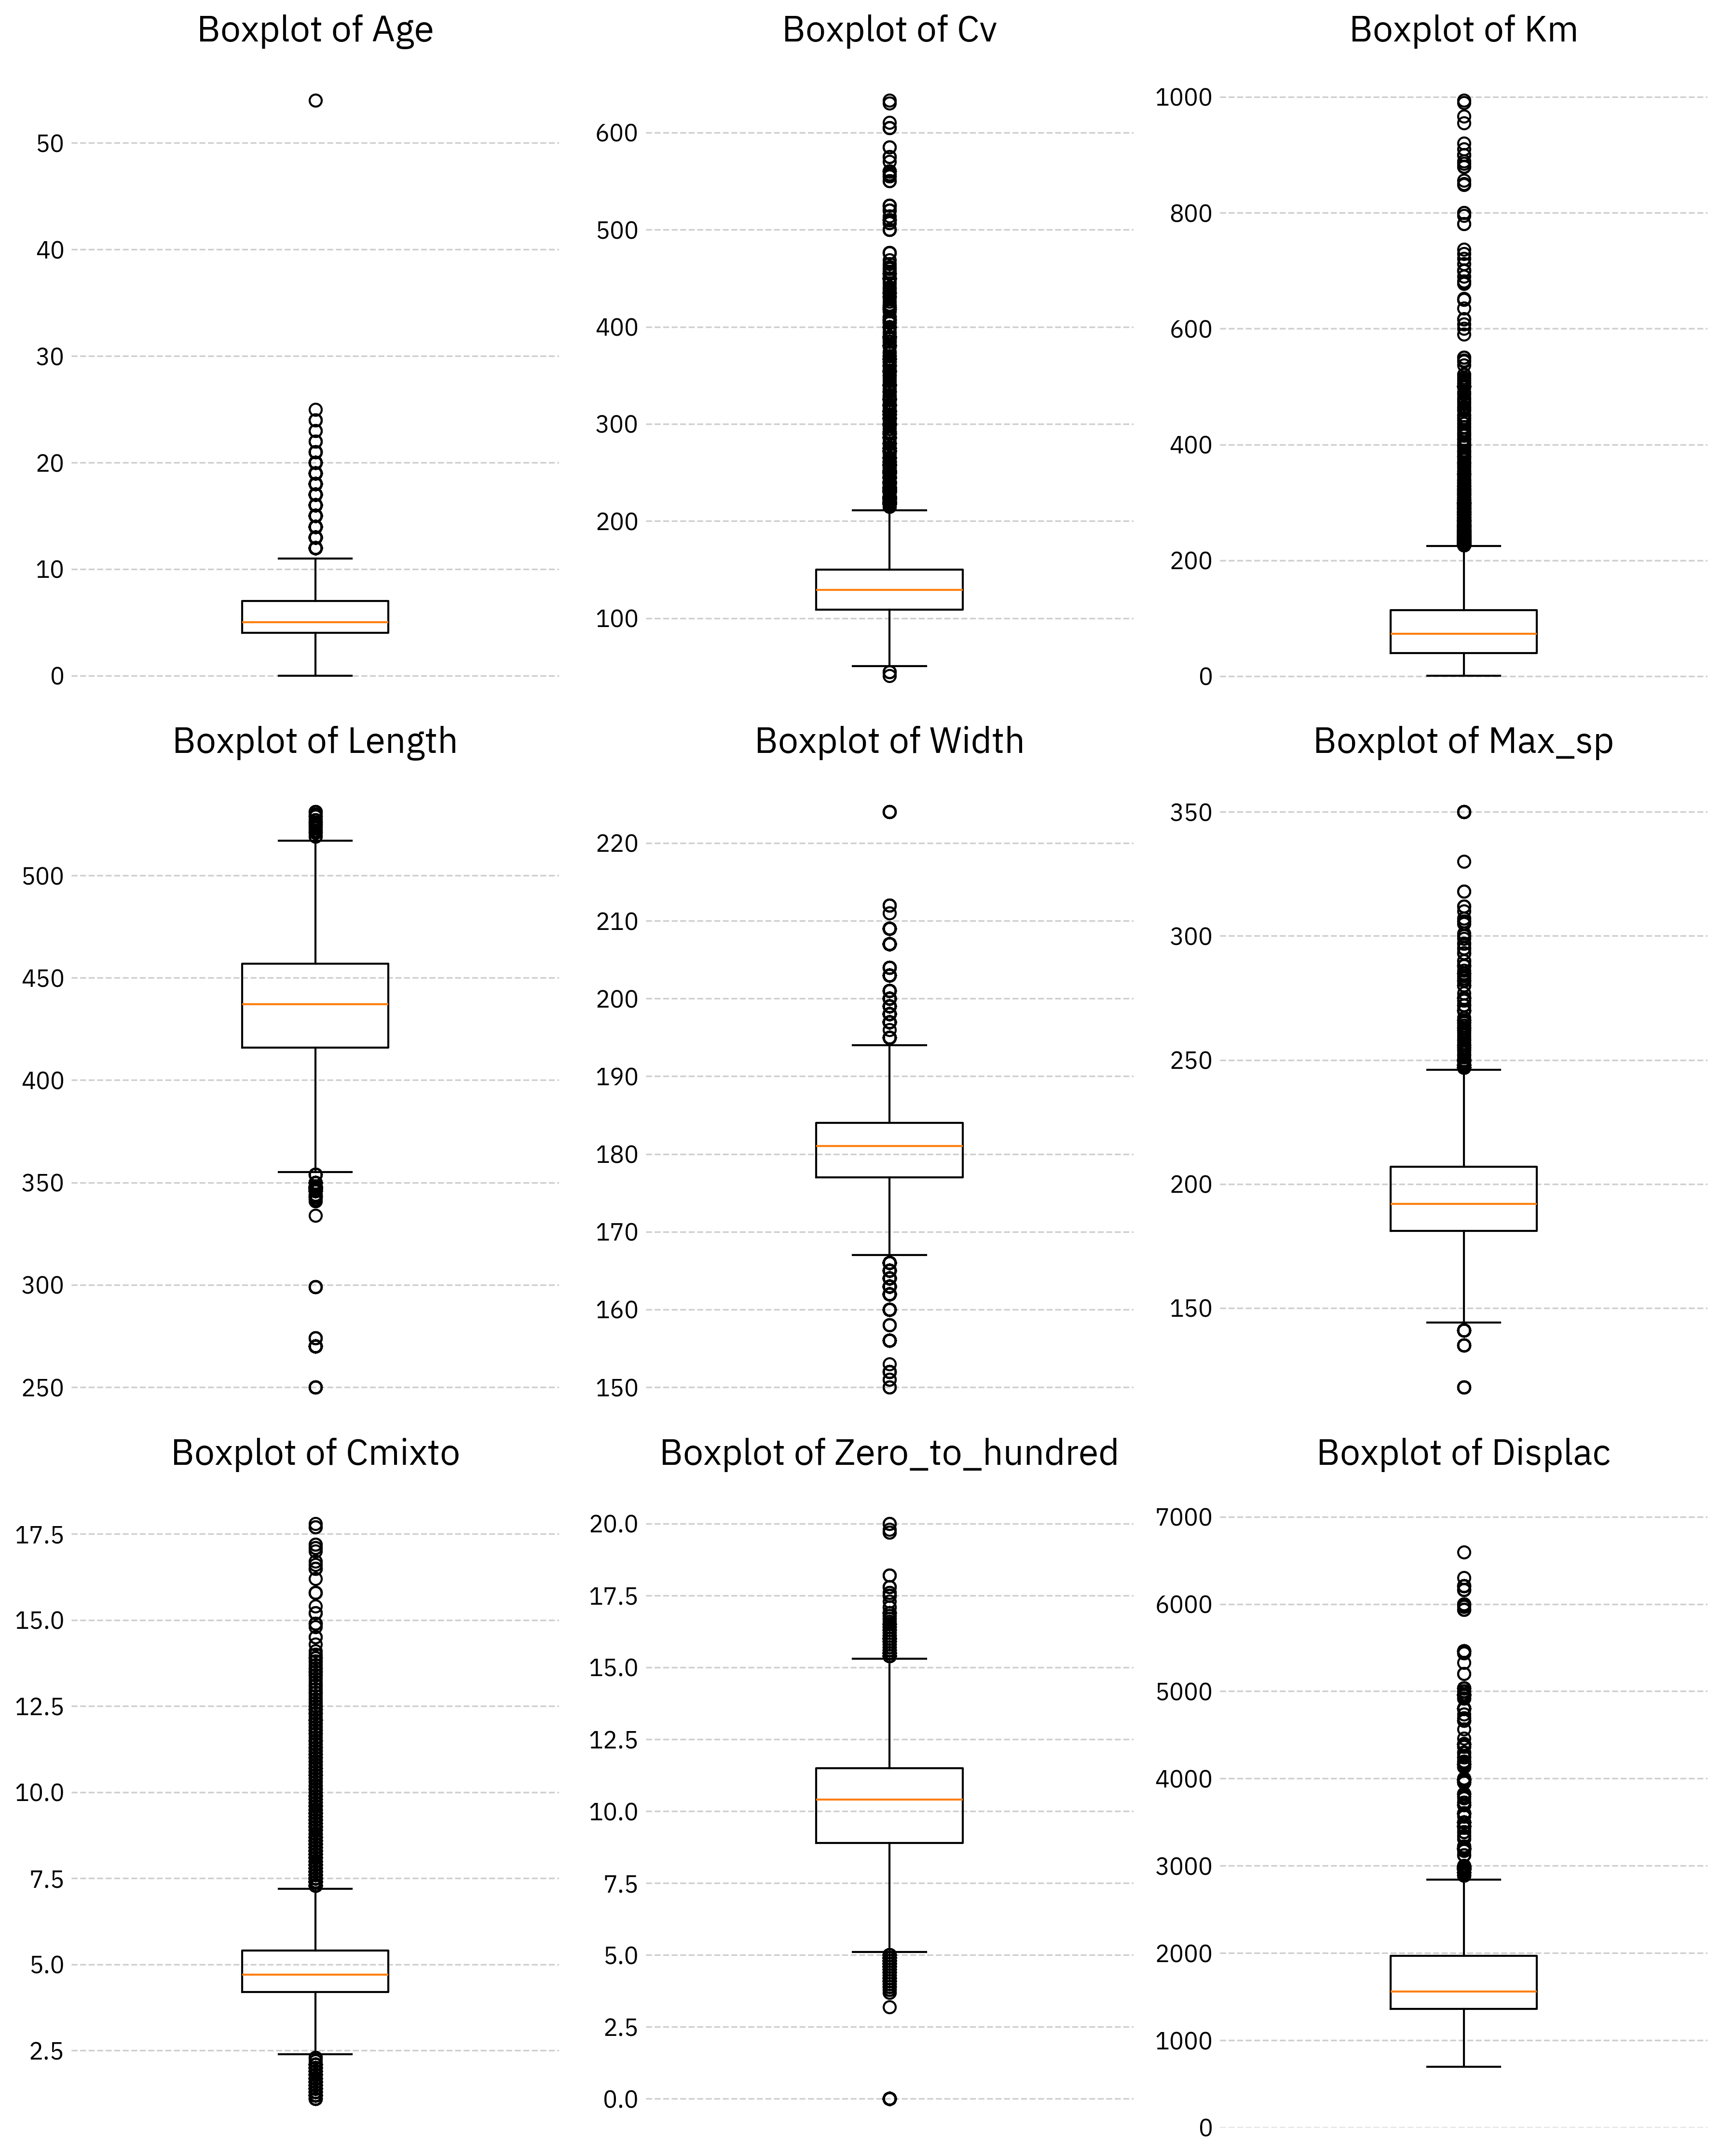

In [19]:
import math
import matplotlib.pyplot as plt

columns = ["age", "cv", "km", "length", "width", "max_sp", "cmixto", "zero_to_hundred", "displac"]

n_cols = 3 
n_rows = math.ceil(len(columns) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 5), dpi=300)

axes = axes.flatten()

for i, col in enumerate(columns):
    ax = axes[i]  
    
    ax.boxplot(df[col], widths=0.3)
    plt.ylim(0, df[col].max()*1.1)
    sp.style_box(ax, title=f"Boxplot of {col.capitalize()}")
for j in range(len(columns), len(axes)):
    fig.delaxes(axes[j])

sp.config.fontname = "IBM Plex Sans"
plt.tight_layout()  
plt.show()

In [20]:
df = remove_top_n_outliers(df, "age", 1)

# 5. Categorical Analysis

For categorical variables, we can use a box plot to visualize the distribution of frequency for each category.

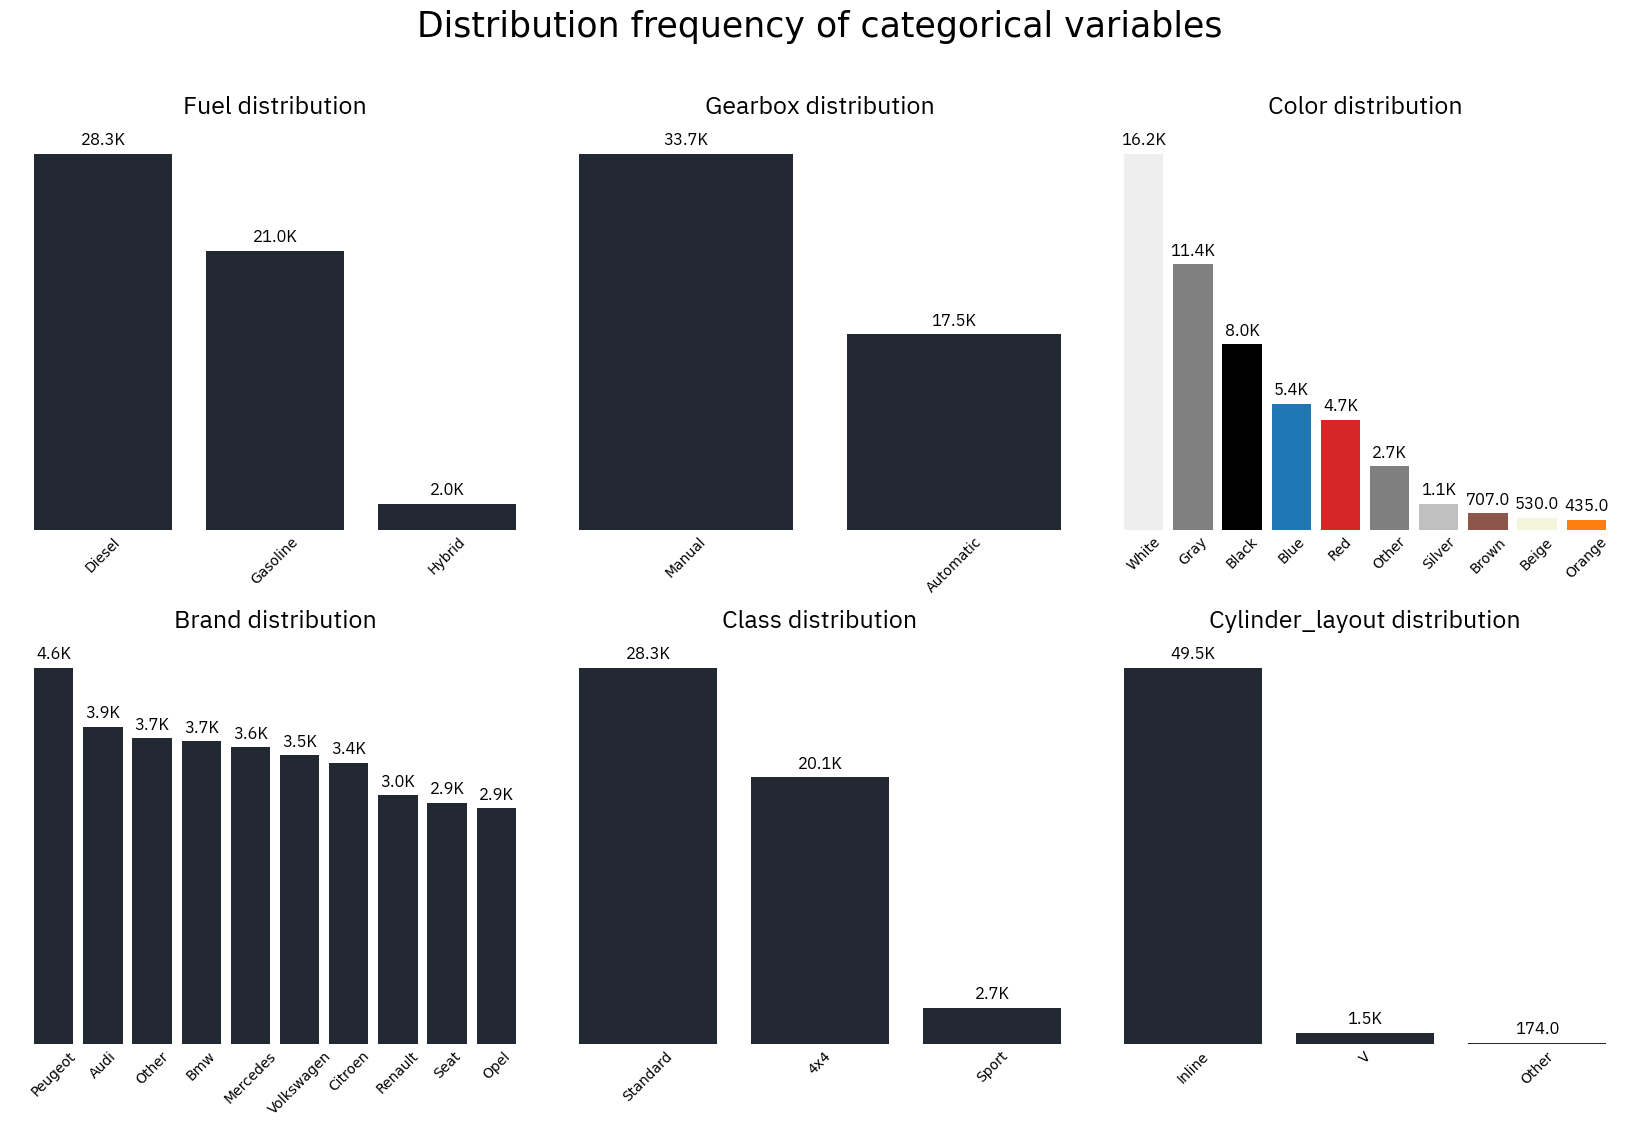

In [111]:
import math
import matplotlib.pyplot as plt

cats = [c for c in df.columns if (df[c].dtype == "object") and (c != "location")] 
n_cols = 3
n_rows = math.ceil(len(cats) / n_cols)

color_map = {
    "White": "#EEEEEE",
    "Gray": "#808080",
    "Black": "#000000",
    "Blue": "#1F77B4",
    "Red": "#D62728",
    "Other": "#7F7F7F",
    "Silver": "#C0C0C0",
    "Brown": "#8C564B",
    "Beige": "#F5F5DC",
    "Orange": "#FF7F0E",
}
default_color = "#222831"

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5.5, n_rows * 5.5),dpi=100)
axes = axes.flatten() if len(cats) > 1 else [axes]
plt.suptitle("Distribution frequency of categorical variables", fontsize=25, y=1.02)
for i, col in enumerate(cats):
    # Slice the top 10 value counts here
    counts = df[col].value_counts().head(10)
    categories = counts.index.astype(str).str.capitalize()
    if col == "color":
        colors = [color_map.get(cat, default_color) for cat in categories]
        bars = axes[i].bar(categories, counts, color=colors)
    else:
        bars = axes[i].bar(categories, counts, color=default_color)

    sp.style_bar(axes[i], title=f"{col.capitalize()} distribution", fmt=sp.formats.human(decimals=1))
    axes[i].tick_params(axis="x", labelrotation=45)

for j in range(len(cats), len(axes)):
    fig.delaxes(axes[j])

sp.config.fontname = "IBM Plex Sans"
plt.tight_layout()
plt.show()

We can also look at the price distribution for each category, which is a quick way to see relationships between the categories and the price. All the variables seem to have some impact on the price, with the exception of color, which seems to have the least impact.

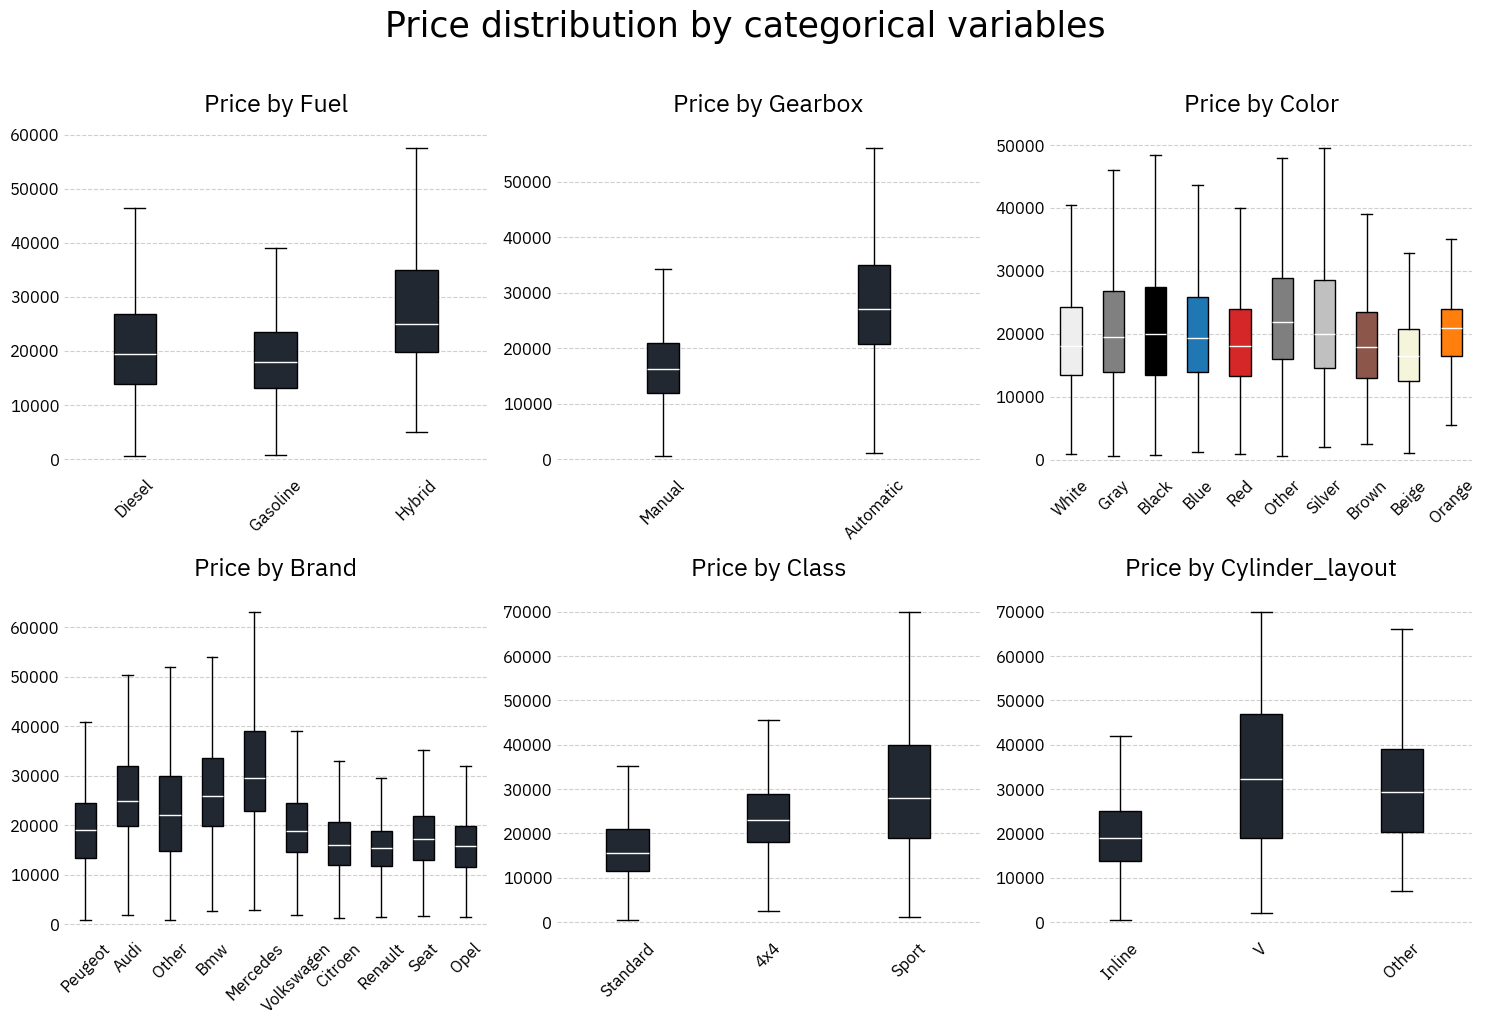

In [ ]:
cats = [c for c in df.columns if (df[c].dtype == "object") and (c != "location")]
n_cols = 3
n_rows = math.ceil(len(cats) / n_cols)

color_map = {
    "White": "#EEEEEE",
    "Gray": "#808080",
    "Black": "#000000",
    "Blue": "#1F77B4",
    "Red": "#D62728",
    "Other": "#7F7F7F",
    "Silver": "#C0C0C0",
    "Brown": "#8C564B",
    "Beige": "#F5F5DC",
    "Orange": "#FF7F0E",
}
default_color = "#222831"

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
plt.subplots_adjust(hspace=2)
axes = axes.flatten() if len(cats) > 1 else [axes]
plt.suptitle("Price distribution by categorical variables", fontsize=25, y=1.02)

for i, col in enumerate(cats):
    # Find the top 10 most frequent categories to keep the plot readable
    top_10_cats = df[col].value_counts().head(10).index
    
    data_to_plot = []
    labels = []
    colors = []
    ax = axes[i]
    # Gather price data for each of the top 10 categories
    for cat in top_10_cats:
        # Extract the prices for the current category, dropping NaNs
        prices = df[df[col] == cat]['price'].dropna()
        
        if not prices.empty:
            data_to_plot.append(prices)
            cat_label = str(cat).capitalize()
            labels.append(cat_label)
            
            # Determine color mapping
            if col == "color":
                colors.append(color_map.get(cat_label, default_color))
            else:
                colors.append(default_color)
                
    if data_to_plot:
        # Create boxplot; patch_artist=True is required to fill the boxes with color
        bplot = axes[i].boxplot(data_to_plot, tick_labels=labels, patch_artist=True, showfliers=False, medianprops=dict(color='white'))
        
        # Apply the colors to each box
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)

    sp.style_box(ax, title=f"Price by {col.capitalize()}", angle=45)


# Remove any empty subplots
for j in range(len(cats), len(axes)):
    fig.delaxes(axes[j])

sp.config.fontname = "IBM Plex Sans"
plt.tight_layout()
plt.show()

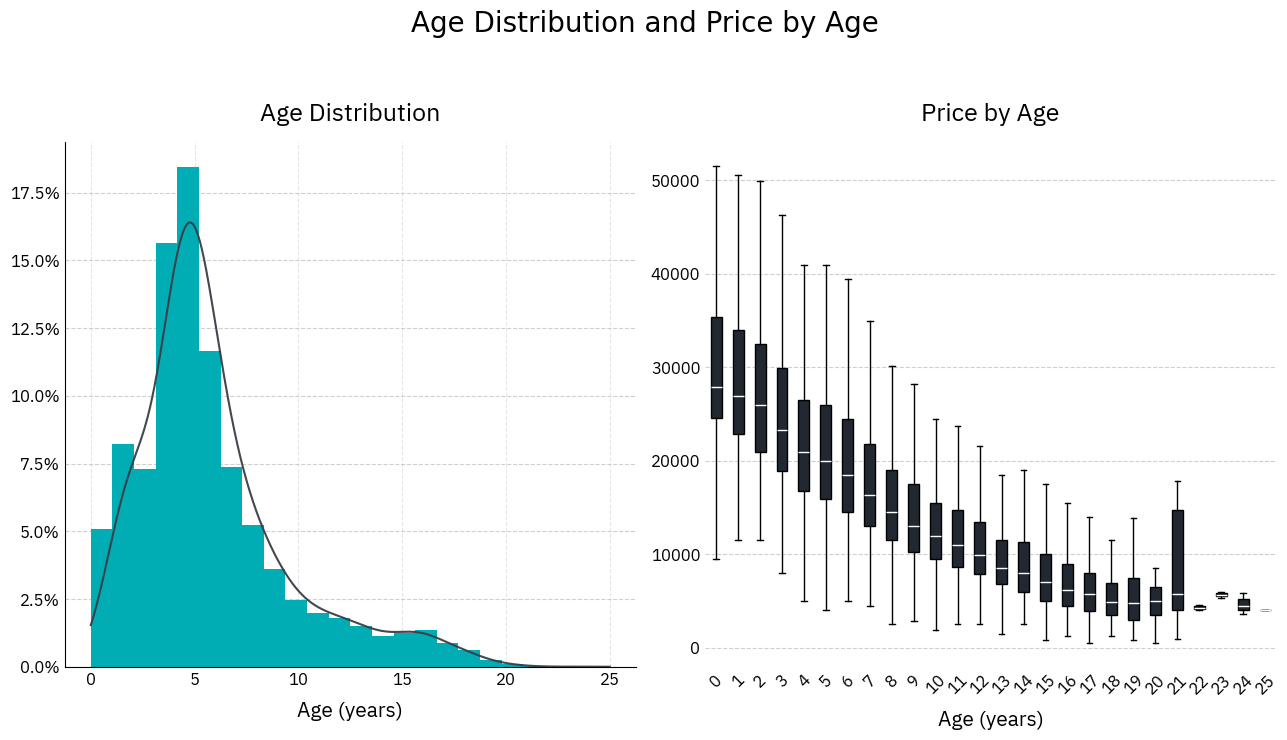

In [157]:
import matplotlib.pyplot as plt

# Define the target column and default color
col = "age"
var = "age"
default_color = "#222831"

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(13, 7), dpi=100)
plt.suptitle(f"Age Distribution and Price by {col.capitalize()}", fontsize=20, y=1.05)

# ---------------------------------------------------------
# Subplot 1: Histogram/KDE for Price Distribution
# ---------------------------------------------------------
color_1, color_2 = "#00ADB5", "#393E46"

# FIX: Added `ax=axes[0]` so it plots in the left panel
df[var].hist(bins=24, density=True, zorder=2, color=color_1, ax=axes[0])

x, y = kde_curve(df[var], bw_adjust=2)
axes[0].plot(x, y, color=color_2, alpha=0.95)

sp.config.fontname = "IBM Plex Sans"

# FIX: Applied styling specifically to `axes[0]`
sp.style_hist(axes[0], yformat=sp.formats.percent(decimals=1), xformat=sp.formats.human(decimals=0), xtitle="Age (years)", title="Age Distribution")

# ---------------------------------------------------------
# Subplot 2: Boxplot for Price Distribution by Age
# ---------------------------------------------------------
data_to_plot = []
labels = []

# FIX: Re-calculate the age categories since we removed the barplot logic from Subplot 1
counts = df[col].value_counts().sort_index()

# Iterate through the sorted age categories
for cat in counts.index:
    # Extract the prices for the current category, dropping NaNs
    prices = df[df[col] == cat]['price'].dropna()
    
    if not prices.empty:
        data_to_plot.append(prices)
        labels.append(str(cat).capitalize())
        
if data_to_plot:
    # Create boxplot
    bplot = axes[1].boxplot(
        data_to_plot, 
        tick_labels=labels, 
        patch_artist=True, 
        showfliers=False, 
        medianprops=dict(color='white')
    )
    
    # Apply the default color to each box
    for patch in bplot['boxes']:
        patch.set_facecolor(default_color)

sp.style_box(axes[1], title=f"Price by {col.capitalize()}", angle=45, xtitle="Age (years)")

# ---------------------------------------------------------
# Final Styling
# ---------------------------------------------------------
sp.config.fontname = "IBM Plex Sans"
plt.tight_layout()
plt.show()